# Convergence of MOU and rDCM derived EC

## Environment setup & index configuration

In [1]:
import os
import os.path
from os.path import dirname, join as pjoin
import numpy as np

import scipy.linalg as spl
import scipy.io as sio
from scipy import stats, odr
from scipy.stats import sem
import scipy.stats as stt

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patheffects as PathEffects
import matplotlib.colors as colors
from matplotlib.ticker import FormatStrFormatter

import seaborn as sb
import pandas as pd


from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.feature_selection import RFE
from sklearn.decomposition import PCA

import networkx as nx

# Jupyter magic commands
%matplotlib inline

### Load MOU Results

In [2]:
out_path = '/home/nicolas/Documents/RetNet/ret-EC/new_results/'

# Index dictionary
conf = {
        'tasks'   : ['vfm','movie','rest'], 
        'eccen'   : ['fovea','para-fovea'], 
        'fovea'   : [ 
                    [0,2,4,6,8,10,12,14,16,18,20,22],  #  < fovea
                    [1,3,5,7,9,11,13,15,17,19,21,23],   #  > fovea
                    ],
        'roiname' : ['V1','V2','V3'], 
        'rois'    : [
                    [0,1,2,3,12,13,14,15],   # V1
                    [4,5,6,7,16,17,18,19],   # V2
                    [8,9,10,11,20,21,22,23]  # V3
                    ],
        'task'    : [
                    [0,1],     # retinotopy
                    [2,3,4,5], # movie watching
                    [6,7,8,9]  # resting state
                    ],

        'hemis'   : ['left', 'right'],
        'flows'   : ['outflow', 'inflow']
        }

# Define the conditions and the corresponding filenames
conditions = conf['tasks']
model = 'new_2021'  # Replace with your actual model name

# Initialize lists to store the loaded data
model_fit_list = []
model_error_list = []
J_mod_list = []
Sigma_mod_list = []
tau_x_list = []
tau_list = []

# Load the MOU results
appendix = model 
model_fit = np.load(os.path.join(out_path, 'Fit_' + appendix + '.npy'))
model_error = np.load(os.path.join(out_path, 'Error_' + appendix + '.npy'))
J_mod = np.load(os.path.join(out_path, 'J_mod_' + appendix + '.npy'))
Sigma_mod = np.load(os.path.join(out_path, 'Sigma_mod_' + appendix + '.npy'))
tau_x = np.load(os.path.join(out_path, 'Tau_rois_' + appendix + '.npy'))
tau = np.load(os.path.join(out_path, 'Tau_mean_' + appendix + '.npy'))


# Print shapes of all arrays to determine the correct axis for subject removal
print("Current shapes before removal:")
print(f"model_fit: {model_fit.shape}")
print(f"model_error: {model_error.shape}")
print(f"J_mod: {J_mod.shape}")
print(f"Sigma_mod: {Sigma_mod.shape}")
print(f"tau_x: {tau_x.shape}")
print(f"tau: {tau.shape}")

Current shapes before removal:
model_fit: (3, 157)
model_error: (3, 157)
J_mod: (3, 157, 24, 24)
Sigma_mod: (3, 157, 24, 24)
tau_x: (157, 3, 24)
tau: ()


## Detect subjects with all-zero matrices in any condition

In [3]:
# Detect subjects with all-zero matrices in any condition
problematic_subjects_any_zero = []
num_subjects = J_mod.shape[1]  # Assuming all conditions have the same number of subjects
num_conditions = J_mod.shape[0]  # 3 conditions: retinotopy, movie, rest

for i_sub in range(num_subjects):
    is_problematic = False
    for cond_idx in range(num_conditions):
        matrix = J_mod[cond_idx][i_sub, :, :]
        if np.all(matrix == 0):
            is_problematic = True
            break  # No need to check further conditions for this subject
    if is_problematic:
        problematic_subjects_any_zero.append(i_sub)

print(f"Subjects with all-zero matrices in at least one condition: {problematic_subjects_any_zero}")
print(f"Total problematic subjects: {len(problematic_subjects_any_zero)}")

# Remove problematic subjects from all arrays (using the list from detection)
# Sort in descending order to avoid index shifting
problematic_subjects_sorted = sorted(problematic_subjects_any_zero, reverse=True)

# Remove from arrays using the correct subject axis for each
model_fit = np.delete(model_fit, problematic_subjects_sorted, axis=1)
model_error = np.delete(model_error, problematic_subjects_sorted, axis=1)
J_mod = np.delete(J_mod, problematic_subjects_sorted, axis=1)
Sigma_mod = np.delete(Sigma_mod, problematic_subjects_sorted, axis=1)
tau_x = np.delete(tau_x, problematic_subjects_sorted, axis=0)
# tau_array has no subject dimension, so leave it unchanged

# Print shapes to verify removal
print("Shapes after removing problematic subjects:")
print(f"model_fit: {model_fit.shape}")
print(f"model_error: {model_error.shape}")
print(f"J_mod_array: {J_mod.shape}")
print(f"Sigma_mod: {Sigma_mod.shape}")
print(f"tau_x: {tau_x.shape}")
print(f"tau: {tau.shape} (unchanged)")

Subjects with all-zero matrices in at least one condition: [114]
Total problematic subjects: 1
Shapes after removing problematic subjects:
model_fit: (3, 156)
model_error: (3, 156)
J_mod_array: (3, 156, 24, 24)
Sigma_mod: (3, 156, 24, 24)
tau_x: (156, 3, 24)
tau: () (unchanged)


## Load rDCM results

In [4]:
# rDCM results path (Julia version)
base_path = '/home/nicolas/Documents/RetNet/ret-EC'
pth = base_path + "/retdata/sorted/"
n_sub = 157  # Changed from 156 to 157
N_rois = 24
EC_dcm = np.zeros([10, n_sub, N_rois, N_rois]) 
F_dcm = np.zeros([10, n_sub])

for i_sub in range(n_sub):
    # Load EC data
    fname = pth + "rDCM_EC_(Julia)_subj_" + str(i_sub+1) + ".npy"
    ec_data = np.load(fname)
    
    # Load F data
    fname_f = pth + "rDCM_F_(Julia)_subj_" + str(i_sub+1) + ".npy"
    f_data = np.load(fname_f)
    
    for i_cond in range(10):
        EC_dcm[i_cond, i_sub, :, :] = ec_data[:, :, i_cond].T
        F_dcm[i_cond, i_sub] = f_data[i_cond]

print('EC_dcm shape:', EC_dcm.shape)

# Average EC_dcm over task conditions, excluding diagonals
EC_avg_dcm = np.zeros((3, n_sub, 24, 24))
diagonals_dcm = np.zeros((3, n_sub, 24))

for i_cond in range(3):
    sessions = conf["task"][i_cond]  # Already 0-based in Python
    for i_sub in range(n_sub):
        avg_matrix = np.mean(EC_dcm[sessions, i_sub, :, :], axis=0)
        diagonals_dcm[i_cond, i_sub, :] = np.diag(avg_matrix)
        avg_matrix -= np.diag(diagonals_dcm[i_cond, i_sub, :])
        EC_avg_dcm[i_cond, i_sub, :, :] = avg_matrix

print('EC_avg_dcm shape:', EC_avg_dcm.shape)
print('diagonals_dcm shape:', diagonals_dcm.shape)

EC_dcm shape: (10, 157, 24, 24)
EC_avg_dcm shape: (3, 157, 24, 24)
diagonals_dcm shape: (3, 157, 24)


## Remove the same problematic subjects from rDCM arrays

In [5]:
print(f"Subjects to remove: {problematic_subjects_any_zero}")

# Remove from rDCM arrays using the correct subject axis
EC_dcm = np.delete(EC_dcm, problematic_subjects_sorted, axis=1)
F_dcm = np.delete(F_dcm, problematic_subjects_sorted, axis=1)
EC_avg_dcm = np.delete(EC_avg_dcm, problematic_subjects_sorted, axis=1)
diagonals_dcm = np.delete(diagonals_dcm, problematic_subjects_sorted, axis=1)


print("\nBoth MOU and rDCM now have matching subjects:")
print(f"MOU J_mod: {J_mod.shape}")
print(f"rDCM EC_avg_dcm: {EC_avg_dcm.shape}")

Subjects to remove: [114]

Both MOU and rDCM now have matching subjects:
MOU J_mod: (3, 156, 24, 24)
rDCM EC_avg_dcm: (3, 156, 24, 24)


## Normalize EC matrices 

To make EC matrices comparable across participants and conditions, each matrix is scaled by its L1 norm. This preserves relative differences in connection strengths while removing variations in overall magnitude.

In [6]:
def normalize_connectivity_matrices(EC_data, normalization_type='L1', verbose=True):
    """
    Normalize effective connectivity matrices using L1 or L2 normalization.
    
    Parameters
    ----------
    EC_data : ndarray
        Effective connectivity data with shape (n_conditions, n_subjects, n_rois, n_rois)
    normalization_type : str, optional
        Type of normalization to apply: 'L1' or 'L2' (default: 'L2')
        - 'L1': Normalize by sum of values (Manhattan norm)
        - 'L2': Normalize by Euclidean norm
    verbose : bool, optional
        Whether to print normalization information (default: True)
    
    Returns
    -------
    EC_normalized : ndarray
        Normalized connectivity matrices with same shape as input
    norm_name : str
        Name of the normalization method used
    
    Notes
    -----
    - Diagonal elements are set to zero before and after normalization
    - If the norm is zero, the matrix is returned unchanged
    """
    # Get dimensions
    n_cond, n_sub, n_rois, _ = EC_data.shape
    
    # Initialize output array
    EC_normalized = np.zeros((n_cond, n_sub, n_rois, n_rois))
    
    # Normalize each condition and subject
    for i_cond in range(n_cond):
        for i_sub in range(n_sub):

            # Get connectivity matrix for this condition and subject
            EC = EC_data[i_cond, i_sub, :, :].copy()
            np.fill_diagonal(EC, 0)  # zero out diagonal
            ECflat  = EC.flatten() # flatten the matrix
            

            # Get off-diagonal elements (link weights)
            EClinks = EC[~np.eye(EC.shape[0],dtype=bool)].reshape(EC.shape[0],-1) # ignore diagonal
            EClinks = EClinks.flatten() # flatten the links
            
            if normalization_type == 'L1':

                norm = sum(EClinks)                
                ECnorm  = ECflat / norm
                ECnorm  = ECnorm.reshape((n_rois, n_rois))

            elif normalization_type == 'L2':

                norm = np.sqrt(sum(EClinks)**2)                
                ECnorm  = ECflat / norm
                ECnorm  = ECnorm.reshape((n_rois, n_rois))
           
            
            # Ensure diagonal remains zero
            np.fill_diagonal(ECnorm, 0)
            
            # Store the normalized matrix
            EC_normalized[i_cond, i_sub, :, :] = ECnorm
    
    # Print information if verbose
    if verbose:
        print(f'EC shape: {EC_normalized.shape}, normalized using {normalization_type} norm')
    
    return EC_normalized


In [7]:
def plot_connectivity_matrix(EC_data, model_name, output_filename, 
                             effect_size_threshold=0.1, 
                             colorbar_label='EC',
                             use_latex=True):
    """
    Plot connectivity matrices with effect sizes for multiple conditions.
    
    Parameters
    ----------
    EC_data : ndarray
        Effective connectivity data with shape (n_conditions, n_subjects, n_rois, n_rois)
    model_name : str
        Model name (e.g., 'new_2021') to determine colormap normalization
    output_filename : str
        Full path for saving the output figure
    effect_size_threshold : float, optional
        Threshold for displaying effect sizes (default: 0.1)
    colorbar_label : str, optional
        Label for the colorbar (default: 'EC')
    use_latex : bool, optional
        Whether to use LaTeX rendering for text (default: True)
    
    Returns
    -------
    fig : matplotlib.figure.Figure
        The created figure object
    ax : array of matplotlib.axes.Axes
        Array of axes objects
    effect_sizes : ndarray
        Computed effect sizes with shape (n_conditions, n_rois, n_rois)
    """
    # Set plot style
    if use_latex:
        plt.rcParams['text.usetex'] = True
        plt.rcParams['font.weight'] = 'bold'
        plt.rcParams['font.family'] = 'serif'
    
    # ROI labels
    rois_sorted = [
        'V1 vf', 'V1 vp', 'V1 df', 'V1 dp',
        'V2 vf', 'V2 vp', 'V2 df', 'V2 dp',
        'V3 vf', 'V3 vp', 'V3 df', 'V3 dp',
        'V1 vf', 'V1 vp', 'V1 df', 'V1 dp',
        'V2 vf', 'V2 vp', 'V2 df', 'V2 dp',
        'V3 vf', 'V3 vp', 'V3 df', 'V3 dp'
    ]
    
    # Cohen's d effect size function
    def cohen_d(group1, group2):
        """Calculate Cohen's d effect size between two groups."""
        mean1, mean2 = np.nanmean(group1), np.nanmean(group2)
        std1, std2 = np.nanstd(group1, ddof=1), np.nanstd(group2, ddof=1)
        n1, n2 = len(group1), len(group2)
        pooled_std = np.sqrt(((n1 - 1) * std1**2 + (n2 - 1) * std2**2) / (n1 + n2 - 2))
        d = (mean1 - mean2) / pooled_std
        return d
    
    # Get dimensions
    n_cond, n_sub, n_rois, _ = EC_data.shape
    
    # Calculate effect sizes
    effect_sizes = np.zeros((n_cond, n_rois, n_rois))
    for i_cond in range(n_cond):
        for roi_p in range(n_rois):
            for roi_q in range(n_rois):
                effect_sizes[i_cond, roi_p, roi_q] = cohen_d(
                    EC_data[i_cond, :, roi_p, roi_q],
                    EC_data[i_cond, :, :, :].flatten()
                )
    
    # Create figure
    fig, ax = plt.subplots(1, n_cond, figsize=(18, 6), dpi=300, facecolor="w")
    
    # Calculate color limits
    EC_min = np.min(np.nanmean(EC_data, axis=1).flatten())
    EC_max = np.max(np.nanmean(EC_data, axis=1).flatten())
    
    # Plot each condition
    for i_cond in range(n_cond):
        # Create colormap normalization
        if model_name == 'new_2021':
            divnorm = colors.TwoSlopeNorm(vmin=EC_min, vcenter=0, vmax=EC_max)
            im = ax[i_cond].imshow(
                np.mean(EC_data[i_cond, :, :, :], axis=0).T,
                norm=divnorm, cmap='BrBG_r'
            )
        else:
            im = ax[i_cond].imshow(
                np.mean(EC_data[i_cond, :, :, :], axis=0).T,
                vmin=EC_min, vmax=EC_max, cmap='Greys'
            )
        
        # Add effect size annotations
        for roi_p in range(n_rois):
            for roi_q in range(n_rois):
                if effect_sizes[i_cond, roi_p, roi_q] >= effect_size_threshold:
                    if roi_p != roi_q:  # Skip diagonal
                        txt = ax[i_cond].text(
                            roi_p, roi_q,
                            f'{effect_sizes[i_cond, roi_p, roi_q]:.1f}',
                            ha='center', va='center', color='black',
                            fontsize=8, rotation=30
                        )
                        txt.set_path_effects([
                            PathEffects.withStroke(linewidth=2, foreground='w')
                        ])
        
        # Set labels and ticks
        ax[i_cond].set_xlabel('Source ROI', fontsize=14)
        ax[i_cond].set_xticks(np.arange(len(rois_sorted)))
        ax[i_cond].set_xticklabels(labels=rois_sorted, rotation=90)
        ax[i_cond].set_ylabel('Target ROI', fontsize=14)
        ax[i_cond].set_yticks(np.arange(len(rois_sorted)))
        ax[i_cond].set_yticklabels(labels=rois_sorted, rotation=0)
        
        # Hide y-labels for subplots after the first
        if i_cond != 0:
            ax[i_cond].set_yticks(np.arange(len(rois_sorted)))
            ax[i_cond].set_yticklabels([''] * len(rois_sorted))
        
        # Set title
        ax[i_cond].set_title(conf['tasks'][i_cond], fontsize=24)
        
        # Add colorbar to first subplot
        if i_cond == 0:
            cbar = plt.colorbar(
                im,
                cax=fig.add_axes([0.32, -0.07, 0.12, 0.024]),
                extend='both',
                orientation='horizontal'
            )
            cbar.ax.tick_params(labelsize=8)
            cbar.set_label(f'EC (${colorbar_label}$)', fontsize=12)
    
    # Save figure
    plt.savefig(
        output_filename,
        transparent=None,
        dpi='figure',
        format='png',
        facecolor='auto',
        edgecolor='auto',
        bbox_inches='tight'
    )
    
    return fig, ax, effect_sizes

In [8]:
EC_normed_MOU = normalize_connectivity_matrices(
    EC_data=J_mod,
    normalization_type='L1',
    verbose=True
)

EC_normed_rDCM = normalize_connectivity_matrices(
    EC_data=EC_avg_dcm,
    normalization_type='L1',
    verbose=True
)

EC shape: (3, 156, 24, 24), normalized using L1 norm
EC shape: (3, 156, 24, 24), normalized using L1 norm


In [9]:
out_pth = '/media/nicolas/KINGSTON/retNet_final/output'

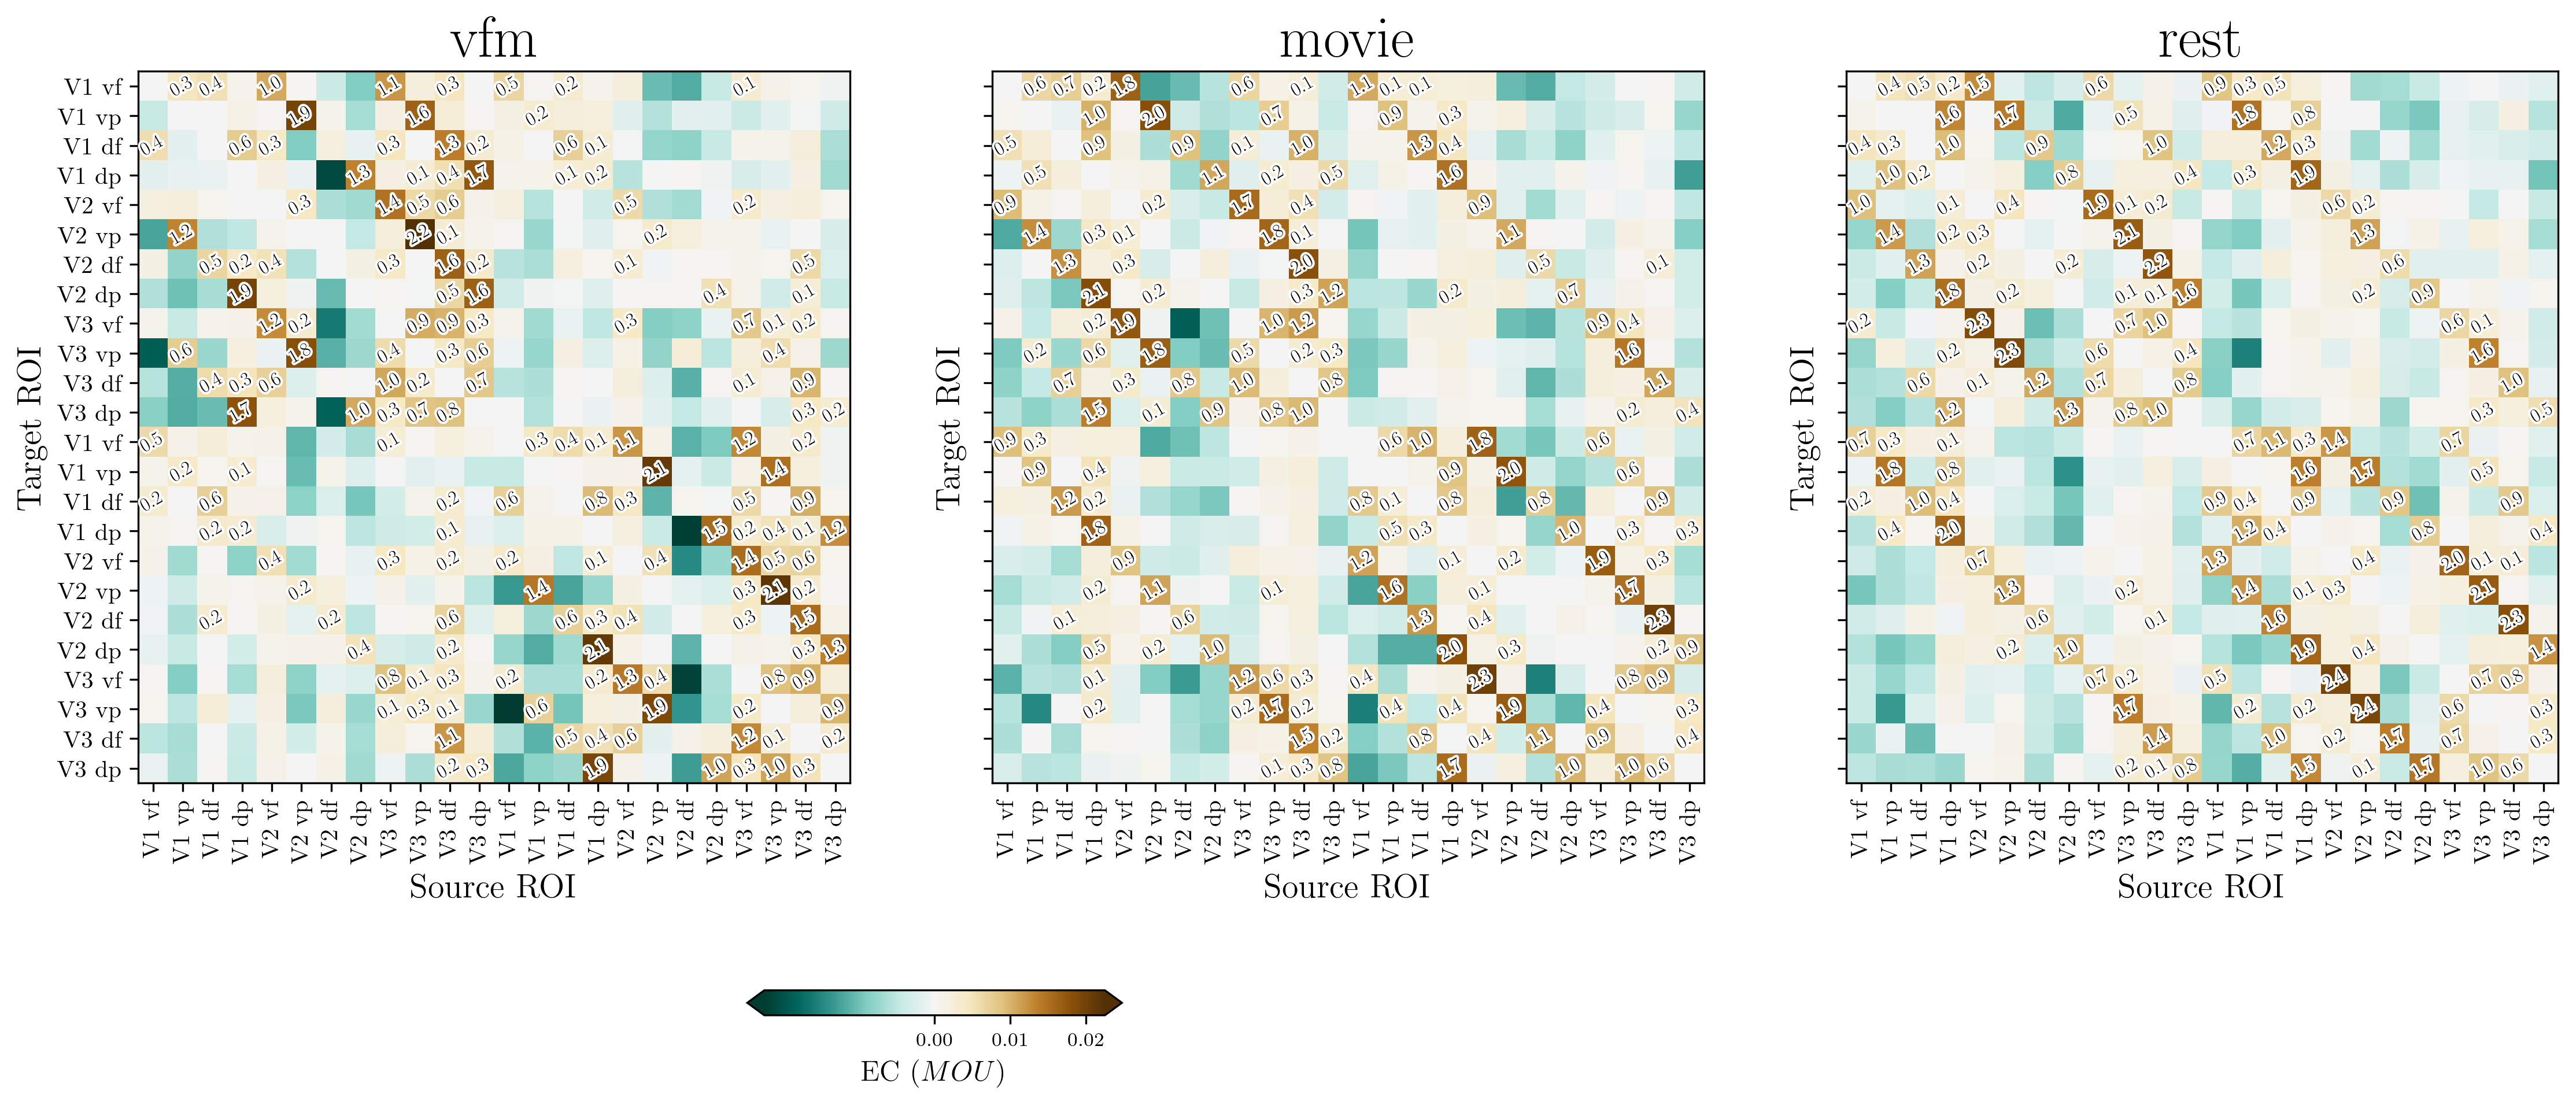

In [10]:
fig, ax, effect_sizes = plot_connectivity_matrix(
    EC_data=EC_normed_MOU,
    model_name=model,
    output_filename=out_pth + 'retNet24_MOU.png',
    effect_size_threshold=0.1,
    colorbar_label='MOU'
)

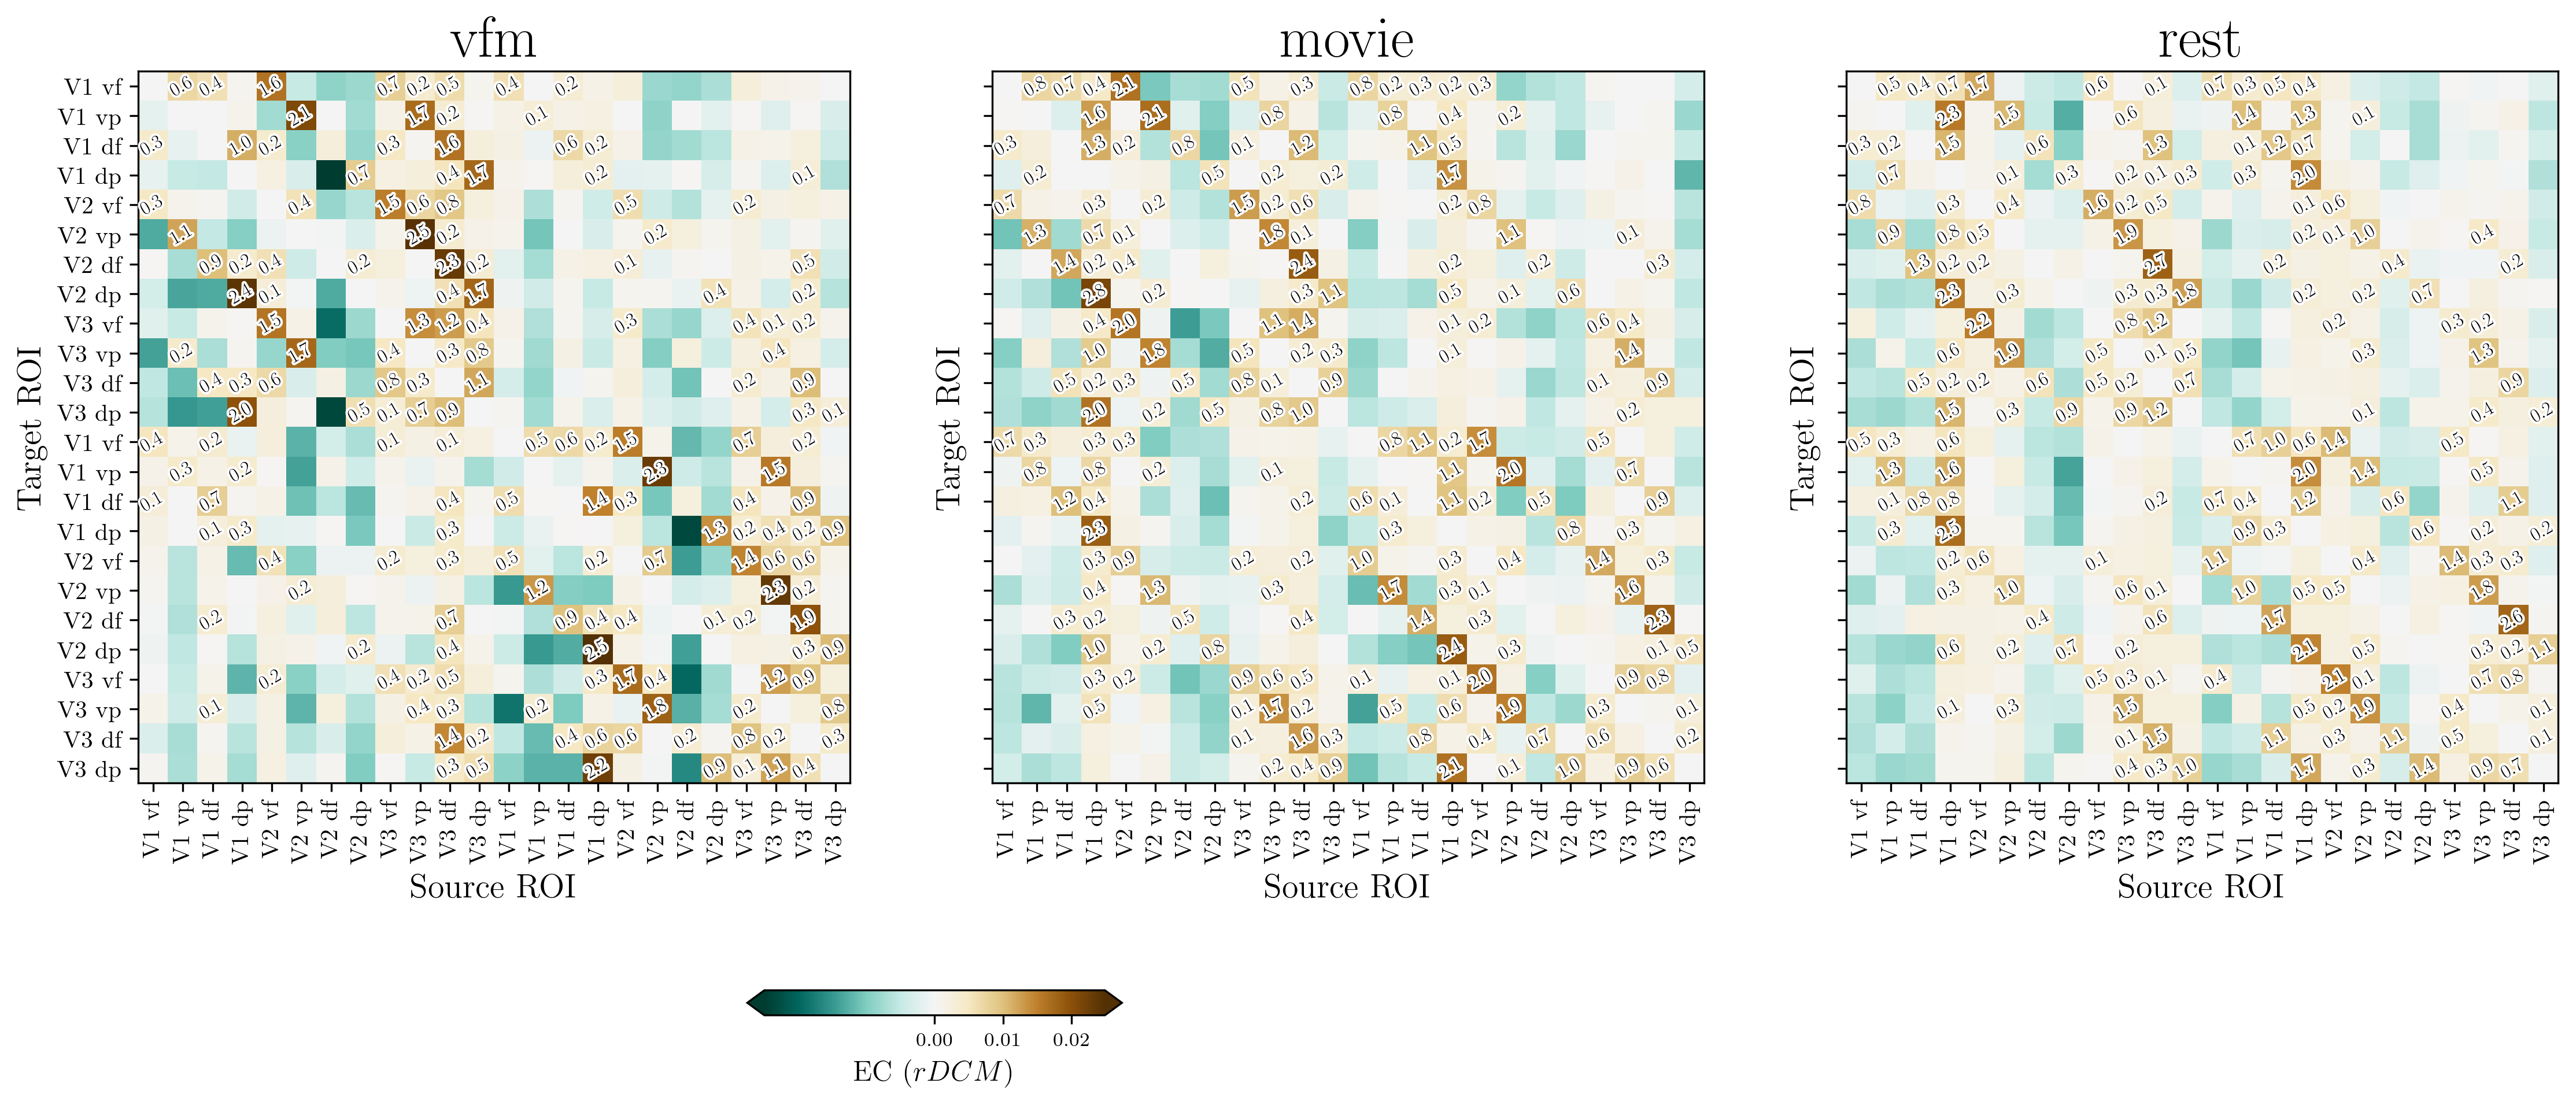

In [11]:
fig, ax, effect_sizes = plot_connectivity_matrix(
    EC_data=EC_normed_rDCM,
    model_name=model,
    output_filename=out_pth + 'retNet24_rDCM.png',
    effect_size_threshold=0.1,
    colorbar_label='rDCM'
)

## Principal Component Analysis

In [14]:
X_mou = EC_normed_MOU.reshape((3*156,24*24))
X_dcm = EC_normed_rDCM.reshape((3*156,24*24))

y = np.repeat(np.arange(3).reshape(3,1),156,axis=1).reshape((3*156))

### MOU

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or R

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or R

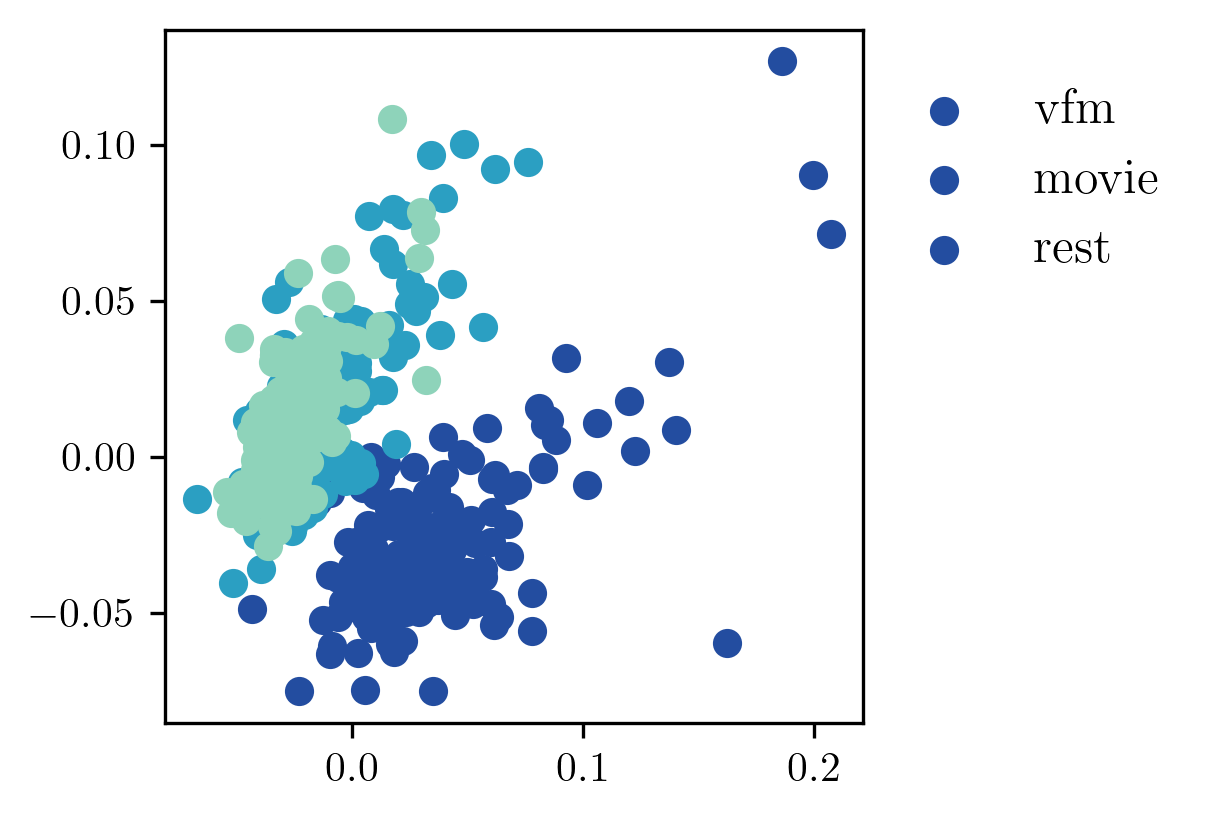

In [15]:
# Imports moved to top cell

pca = PCA(n_components=2)

fig, ax = plt.subplots(figsize=(3,3), dpi=300, facecolor="w")
n = 9
colors = plt.cm.YlGnBu_r(np.linspace(0.2,0.8,n))

x_pca = pca.fit_transform(X_mou)

cols = ['r', 'g', 'b']
for i in range(156*3):
    ax.scatter(x_pca[i,0], x_pca[i,1], c=colors[int(y[i])*3]) #    cols[int(y[i])])

ax.legend(['vfm','movie','rest '], frameon=False,bbox_to_anchor=(0.98, 0.98),fontsize=12,  title="", loc=2, prop={'size':12})

fname = out_pth + 'PCA_MOU.svg' 
plt.savefig(fname, transparent=None, dpi='figure', format='svg',
    facecolor='auto', edgecolor='auto',bbox_inches='tight')

### rDCM

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or R

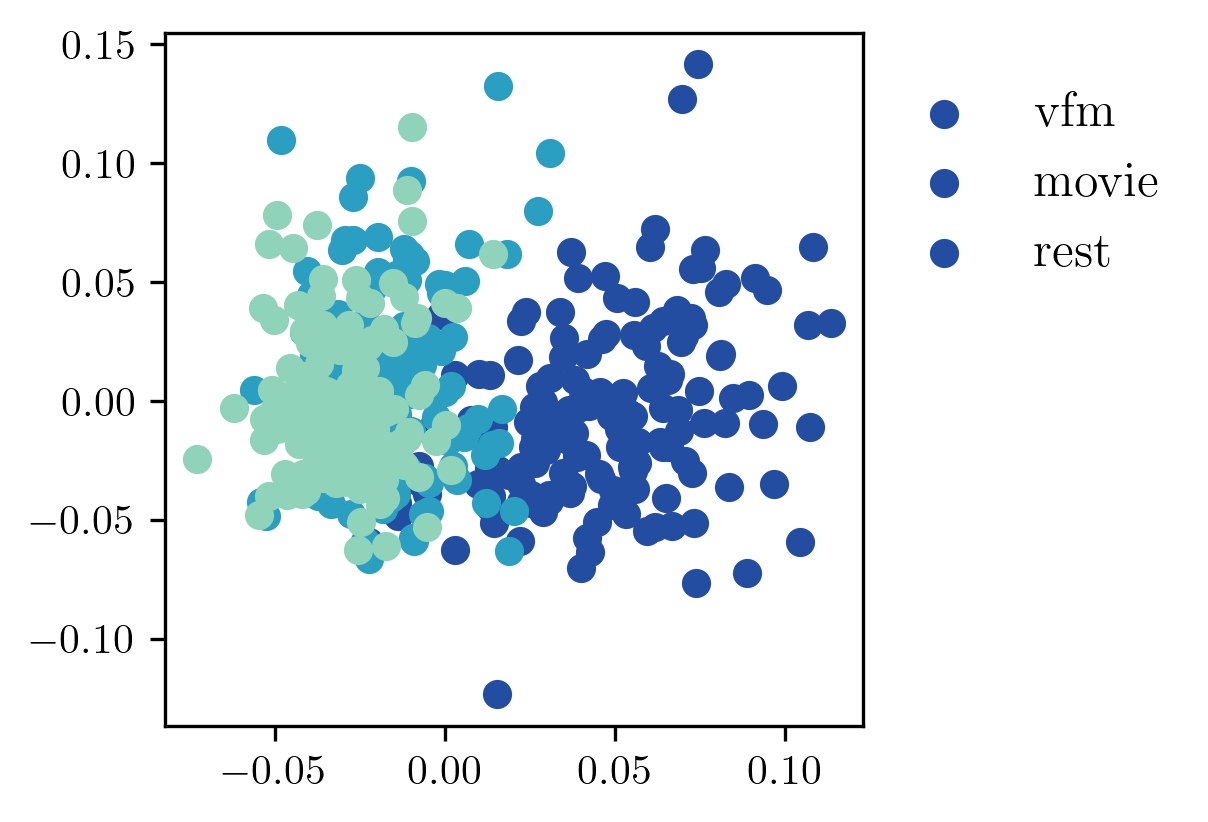

In [16]:
# Imports moved to top cell

pca = PCA(n_components=2)

fig, ax = plt.subplots(figsize=(3,3), dpi=300, facecolor="w")
n = 9
colors = plt.cm.YlGnBu_r(np.linspace(0.2,0.8,n))

x_pca = pca.fit_transform(X_dcm)

cols = ['r', 'g', 'b']
for i in range(156*3):
    ax.scatter(x_pca[i,0], x_pca[i,1], c=colors[int(y[i])*3]) #    cols[int(y[i])])

ax.legend(['vfm','movie','rest '], frameon=False,bbox_to_anchor=(0.98, 0.98),fontsize=12,  title="", loc=2, prop={'size':12})

fname = out_pth + 'PCA_rDCM.svg' 
plt.savefig(fname, transparent=None, dpi='figure', format='svg',
    facecolor='auto', edgecolor='auto',bbox_inches='tight')


### MOU vs rDCM

Text(0.5, 1.0, 'PearsonRResult(statistic=0.8476521705327862, pvalue=0.0)')

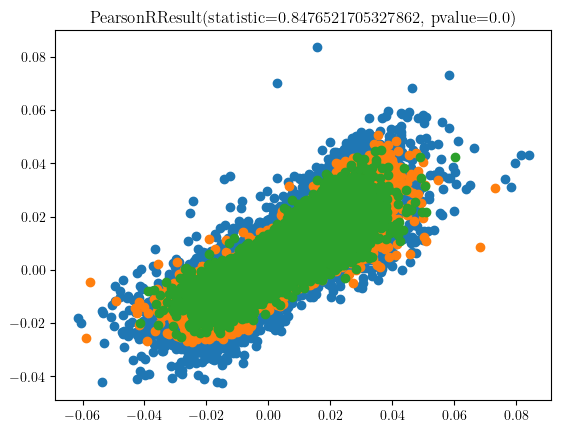

In [ ]:

plt.scatter(EC_normed_MOU[0,:,:,:].flatten(), EC_normed_rDCM[0,:,:,:].flatten())
plt.title(stt.pearsonr(EC_normed_MOU[0,:,:,:].flatten(),EC_dcm[0,:,:,:].flatten()))


plt.scatter(EC_normed_MOU[1,:,:,:].flatten(), EC_normed_rDCM[1,:,:,:].flatten())
plt.title(stt.pearsonr(EC_normed_MOU[1,:,:,:].flatten(),EC_normed_rDCM[1,:,:,:].flatten()))


plt.scatter(EC_normed_MOU[2,:,:,:].flatten(), EC_normed_rDCM[2,:,:,:].flatten())
plt.title(stt.pearsonr(EC_normed_MOU[2,:,:,:].flatten(),EC_normed_rDCM[2,:,:,:].flatten()))


## Variability in within-hemisphere connections

(3, 314, 12, 12)
PearsonRResult(statistic=0.9260894211209971, pvalue=5.598551765950918e-62)
PearsonRResult(statistic=0.9719730280502421, pvalue=3.573373597049516e-91)
PearsonRResult(statistic=0.9286876445442755, pvalue=4.841458737470439e-63)


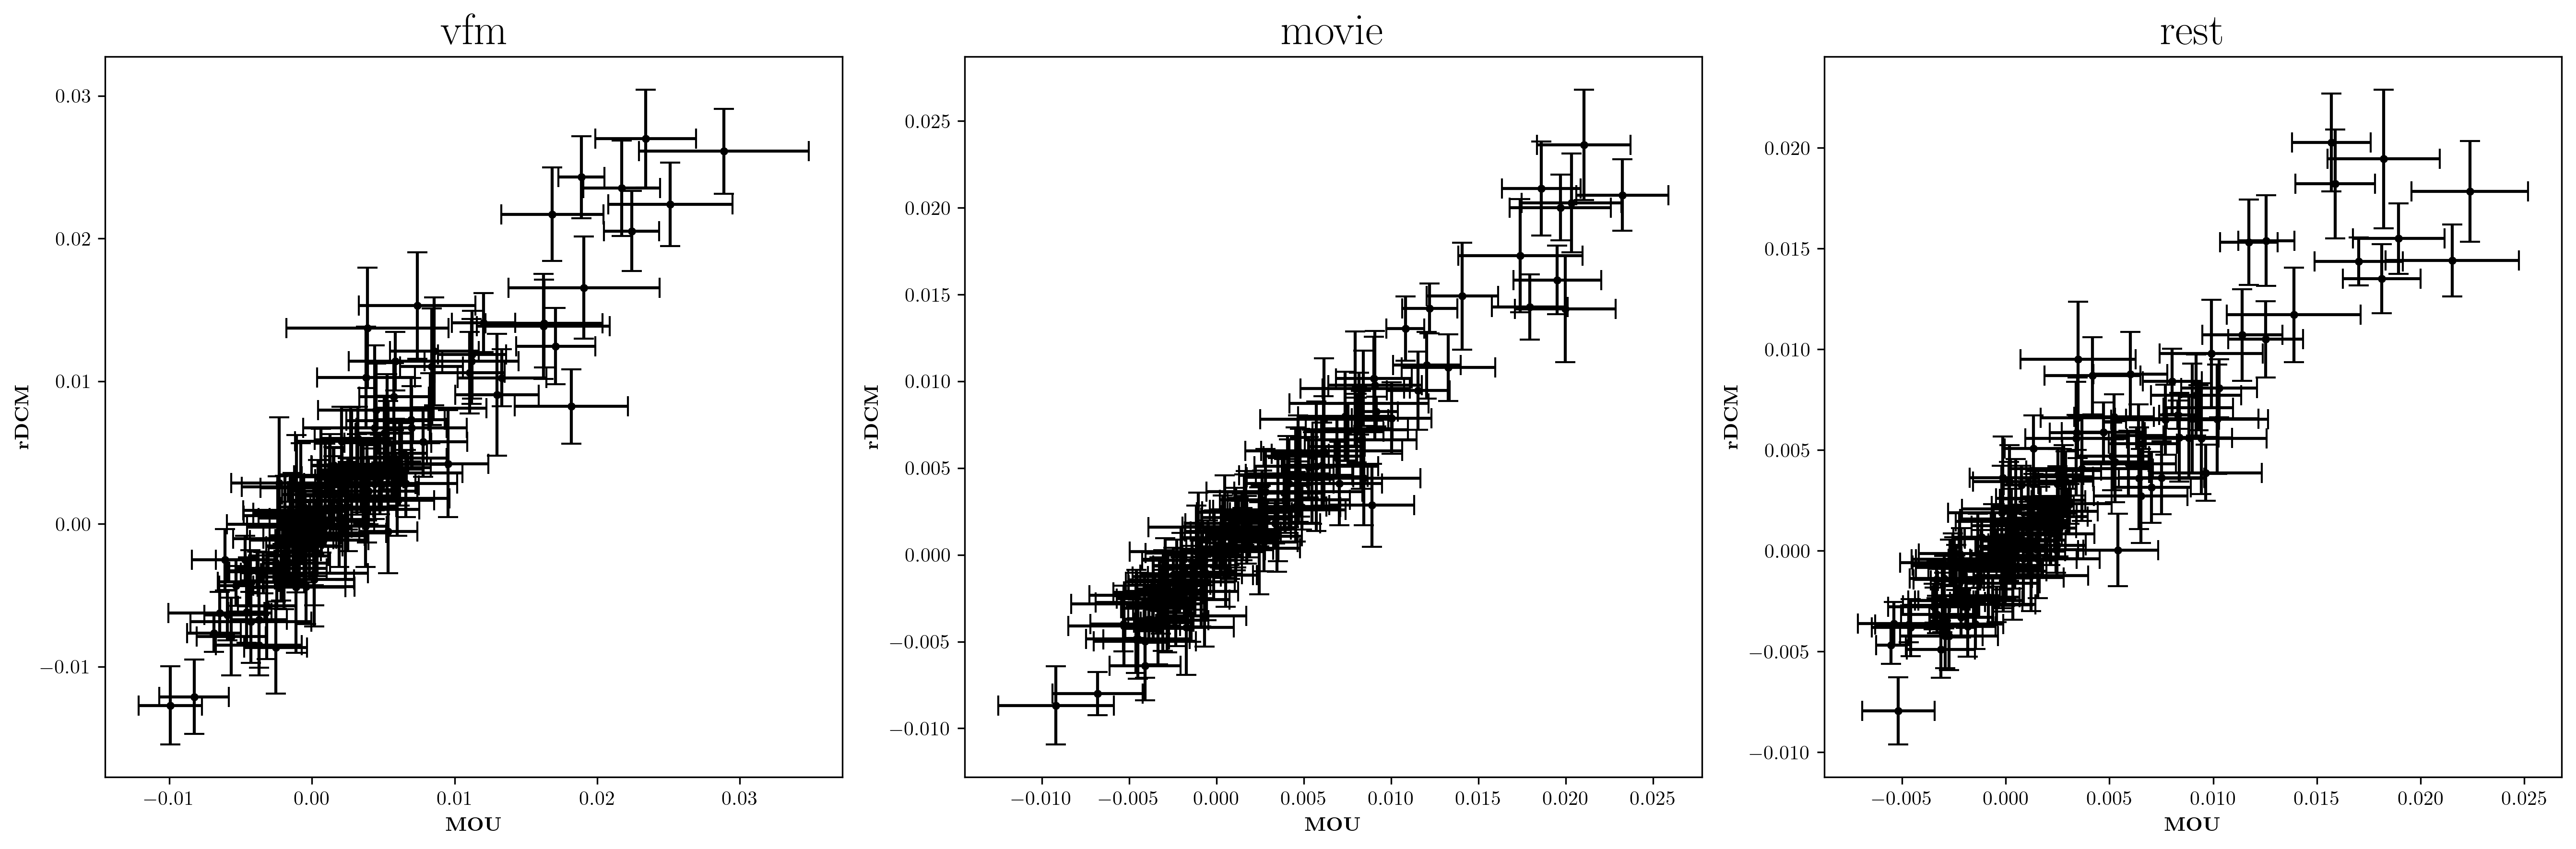

In [22]:
# Imports moved to top cell

n_rois = 12
n_cond = 3


rois_sorted = ['$ventral \mathbf{V1}_{fovea}$',
        '$ventral \mathbf{V1}_{parafovea}$',
        '$dorsal \mathbf{V1}_{fovea}$',
        '$dorsal \mathbf{V1}_{parafovea}$',
        '$ventral \mathbf{V2}_{fovea}$', 
        '$ventral \mathbf{V2}_{parafovea}$',
        '$dorsal \mathbf{V2}_{fovea}$', 
        '$dorsal \mathbf{V2}_{parafovea}$',
        '$ventral \mathbf{V3}_{fovea}$',
        '$ventral \mathbf{V3}_{parafovea}$',
        '$dorsal \mathbf{V3}_{fovea}$',
        '$dorsal \mathbf{V3}_{parafovea}$']


EC_hemis_mou = np.zeros([n_cond,2*n_sub,12,12])
EC_hemis_dcm = np.zeros([n_cond,2*n_sub,12,12])

for i_cond in range(n_cond):
    for i_sub in range(n_sub): 
        EC_hemis_mou[i_cond,0:n_sub,:,:]       = np.nanmean(EC_normed_MOU[i_cond,:,0:12,0:12],axis=0)
        EC_hemis_mou[i_cond,n_sub:2*n_sub,:,:] = np.nanmean(EC_normed_MOU[i_cond,:,12:24,12:24],axis=0)
        EC_hemis_dcm[i_cond,0:n_sub,:,:]       = np.nanmean(EC_normed_rDCM[i_cond,:,0:12,0:12],axis=0)
        EC_hemis_dcm[i_cond,n_sub:2*n_sub,:,:] = np.nanmean(EC_normed_rDCM[i_cond,:,12:24,12:24],axis=0)
        



print(EC_hemis_mou.shape)

# Assuming EC_mou and EC_dcm are already defined
fig, ax = plt.subplots(1,3, figsize=(18,6), dpi=300,facecolor="w", constrained_layout=True)

colors = plt.cm.YlGnBu_r(np.linspace(0.2,0.8,12))

xm = np.zeros((3,12,12))
ym = np.zeros((3,12,12))

for i_cond in range(n_cond):  
    ax[i_cond].set_title(conf['tasks'][i_cond], fontsize=22)


    for p in range(12):
        for q in range(12):
            x = EC_normed_MOU[i_cond, :10, p, q].flatten()
            y = EC_normed_rDCM[i_cond, :10, p, q].flatten()
            xm[i_cond,p,q] = np.mean(x)
            ym[i_cond,p,q] = np.mean(y)
            xerr = sem(x)
            yerr = sem(y)
        
            color = 'Black' #colors[p]  # Get color from colormap

            ax[i_cond].errorbar(xm[i_cond,p,q], ym[i_cond,p,q], xerr=xerr, yerr=yerr, fmt='.', capsize=5,label=rois_sorted[p], color=color)

    ax[i_cond].set_xlabel('$\mathbf{MOU}$')
    ax[i_cond].set_ylabel('$\mathbf{rDCM}$')

plt.tight_layout()



# stats
for i_cond in range(n_cond):
    print(stt.pearsonr(xm[i_cond,:,:].flatten(), ym[i_cond,:,:].flatten()))



fname = out_pth + 'withinHemis_Alignment.png' 
plt.savefig(fname, transparent=None, dpi='figure', format='png',
    facecolor='auto', edgecolor='auto',bbox_inches='tight')

    #plt.legend(labels=rois_sorted,loc='center left', bbox_to_anchor=(1.05, 0.45), frameon=False)
plt.show()


## Variability in callosal connections

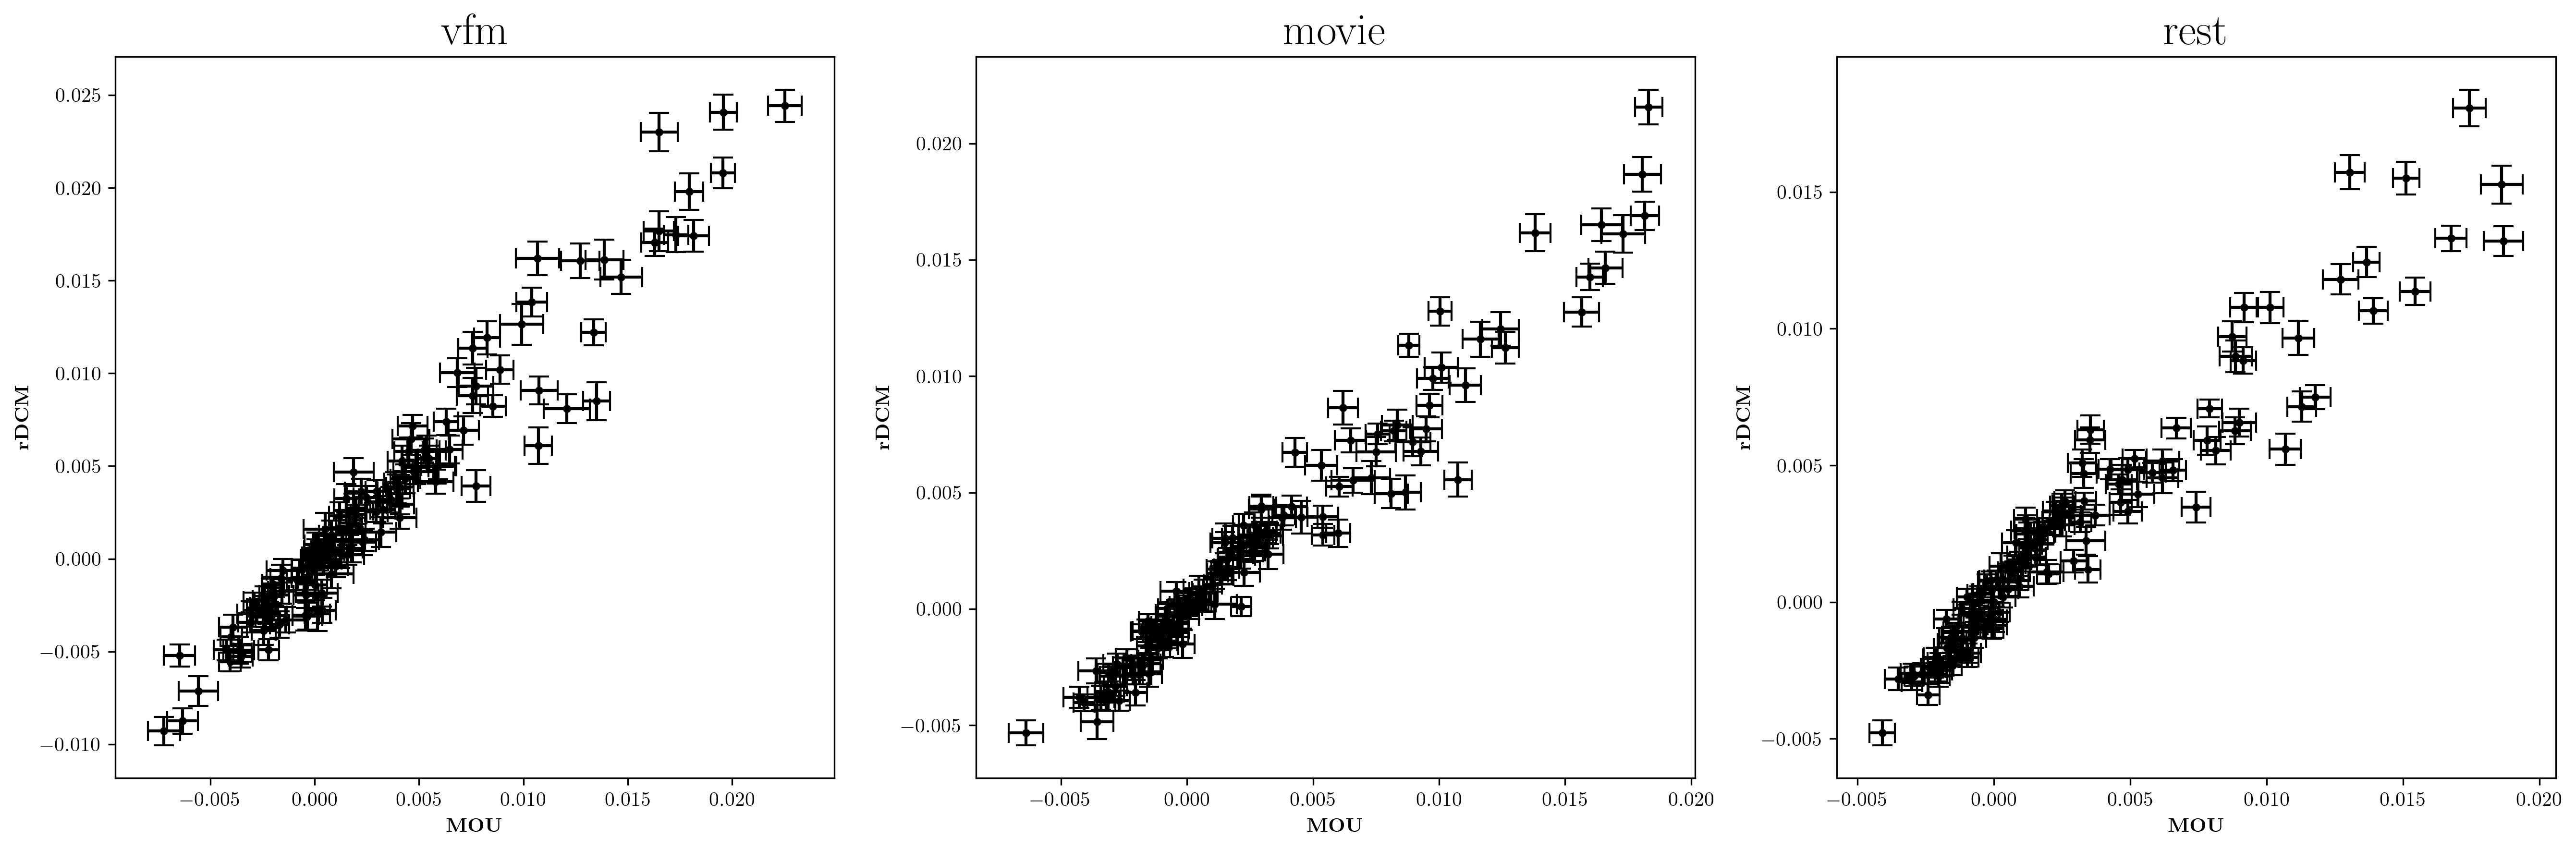

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import sem

n_rois = 12
n_cond = 3


rois_sorted = ['$ventral \mathbf{V1}_{fovea}$',
        '$ventral \mathbf{V1}_{parafovea}$',
        '$dorsal \mathbf{V1}_{fovea}$',
        '$dorsal \mathbf{V1}_{parafovea}$',
        '$ventral \mathbf{V2}_{fovea}$', 
        '$ventral \mathbf{V2}_{parafovea}$',
        '$dorsal \mathbf{V2}_{fovea}$', 
        '$dorsal \mathbf{V2}_{parafovea}$',
        '$ventral \mathbf{V3}_{fovea}$',
        '$ventral \mathbf{V3}_{parafovea}$',
        '$dorsal \mathbf{V3}_{fovea}$',
        '$dorsal \mathbf{V3}_{parafovea}$']


EC_hemis_mou = np.zeros([n_cond,2*n_sub,12,12])
EC_hemis_dcm = np.zeros([n_cond,2*n_sub,12,12])

for i_cond in range(n_cond):
    for i_sub in range(n_sub): 
        EC_hemis_mou[i_cond,0:n_sub,:,:]       = np.nanmean(EC_normed_MOU[i_cond,:,0:12,12:24],axis=0)
        EC_hemis_mou[i_cond,n_sub:2*n_sub,:,:] = np.nanmean(EC_normed_MOU[i_cond,:,12:24,0:12],axis=0)
        EC_hemis_dcm[i_cond,0:n_sub,:,:]       = np.nanmean(EC_normed_rDCM[i_cond,:,0:12,12:24],axis=0)
        EC_hemis_dcm[i_cond,n_sub:2*n_sub,:,:] = np.nanmean(EC_normed_rDCM[i_cond,:,12:24,0:12],axis=0)
        



# Assuming EC_mou and EC_dcm are already defined
fig, ax = plt.subplots(1,3, figsize=(18,6), dpi=300,facecolor="w", constrained_layout=True)

colors = plt.cm.YlGnBu_r(np.linspace(0.2,0.8,12))

xm = np.zeros((3,12,12))
ym = np.zeros((3,12,12))

for i_cond in range(n_cond):  
    ax[i_cond].set_title(conf['tasks'][i_cond], fontsize=22)


    for p in range(12):
        for q in range(12):
            x = EC_normed_MOU[i_cond, :, p, q].flatten()
            y = EC_normed_rDCM[i_cond, :, p, q].flatten()
            xm[i_cond,p,q] = np.mean(x)
            ym[i_cond,p,q] = np.mean(y)
            xerr = sem(x)
            yerr = sem(y)
        
            color = 'Black' #colors[p]  # Get color from colormap

            ax[i_cond].errorbar(xm[i_cond,p,q], ym[i_cond,p,q], xerr=xerr, yerr=yerr, fmt='.', capsize=5,label=rois_sorted[p], color=color)

    ax[i_cond].set_xlabel('$\mathbf{MOU}$')
    ax[i_cond].set_ylabel('$\mathbf{rDCM}$')

plt.tight_layout()



fname = out_pth + 'betweenHemis_Alignment.png' 
plt.savefig(fname, transparent=None, dpi='figure', format='png',
    facecolor='auto', edgecolor='auto',bbox_inches='tight')


#plt.legend(labels=rois_sorted,loc='center left', bbox_to_anchor=(1.05, 0.45), frameon=False)
plt.show()


Callosal connections are less affected by local vascular signal spread across V1–V3 and therefore exhibit lower variability.

## Model convergence

MOU and rDCM estimates are robustly correlated and stabilize > participants.

(10, 156, 24, 24)
[  2   4   8  16  32  64 128]


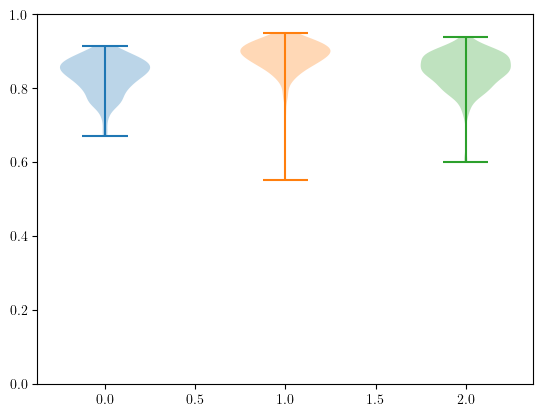

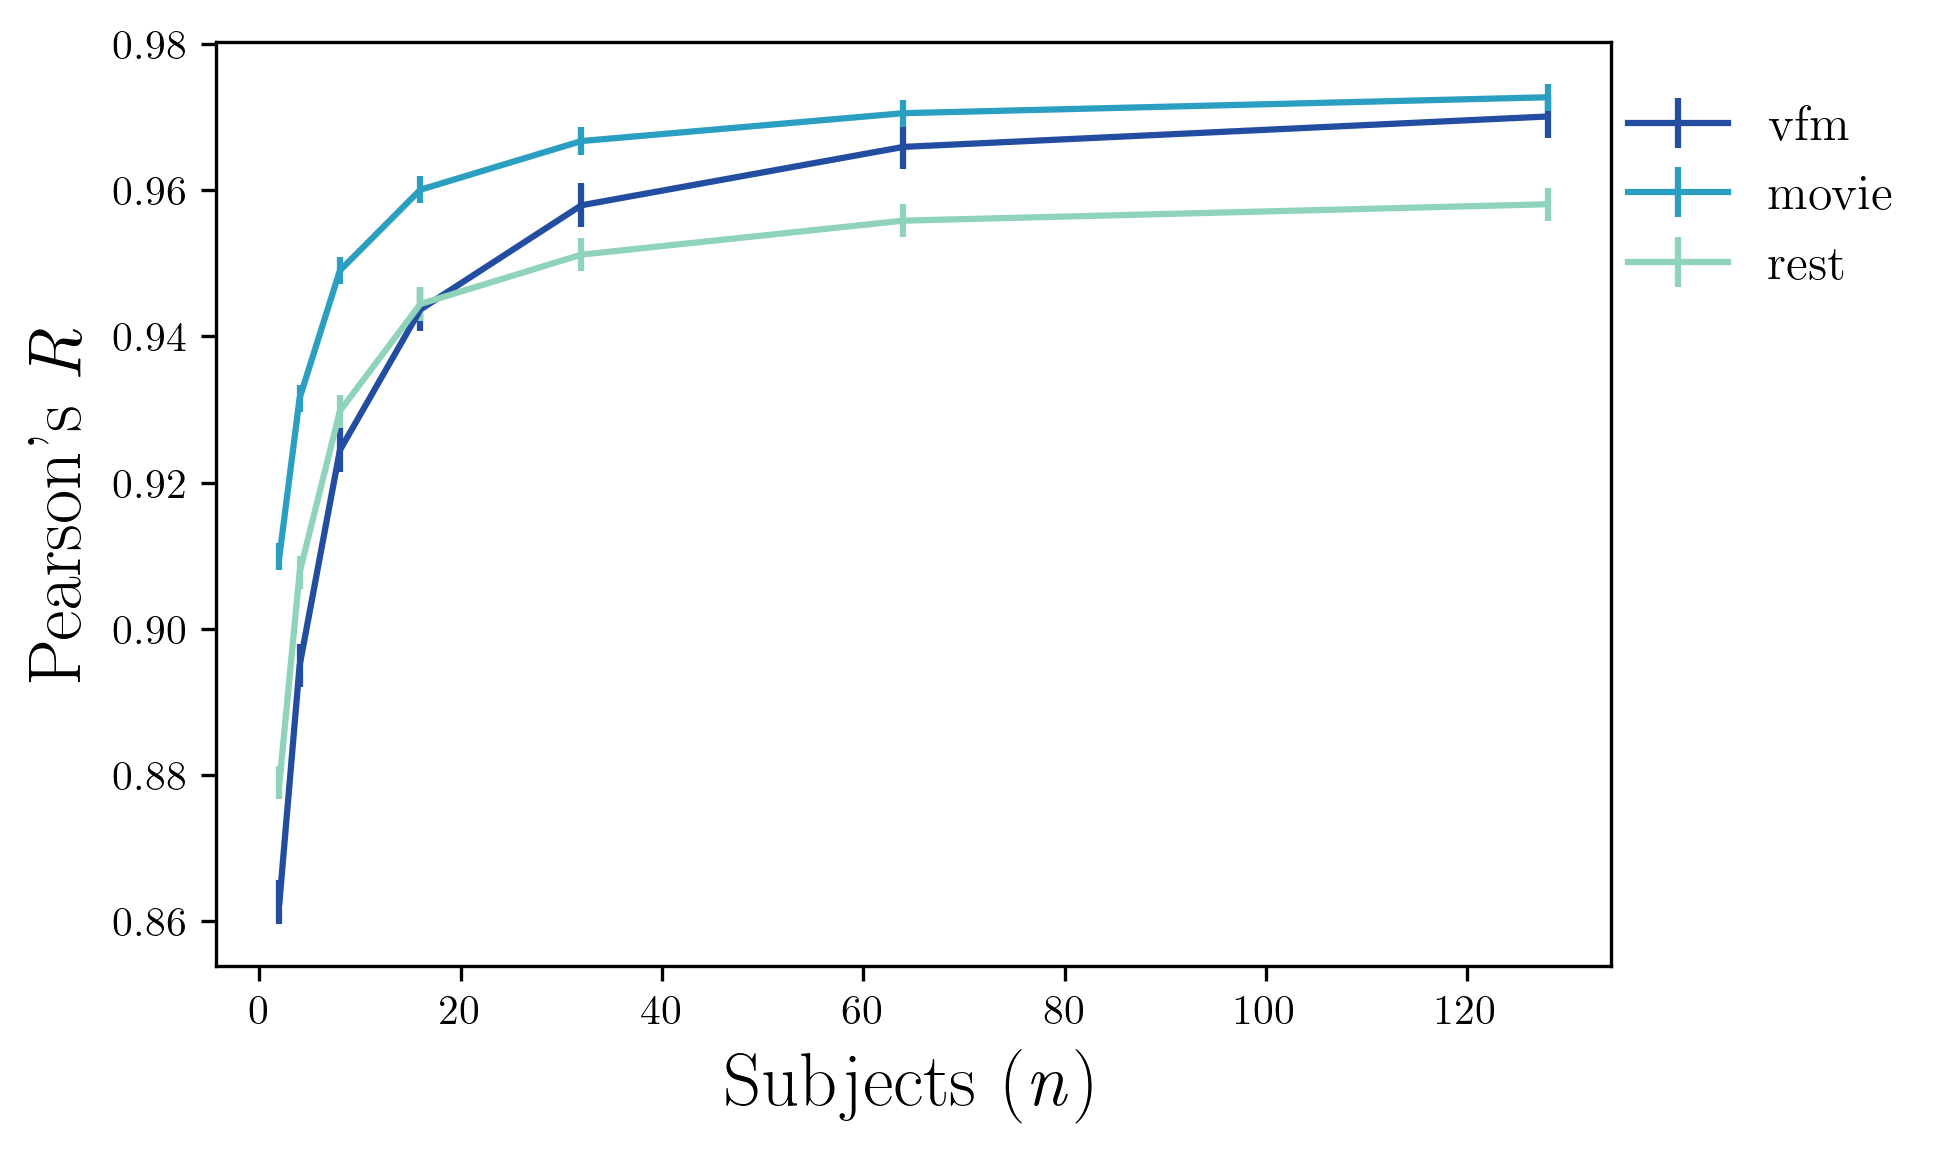

In [28]:
n = 9
colors = plt.cm.YlGnBu_r(np.linspace(0.2,0.8,n))


# stats
R2_cond = []
for i_cond in range(n_cond):
    R2_cond.append([])
    for i_sub in range(156):
        R2_cond[i_cond].append(stt.pearsonr(EC_normed_rDCM[i_cond,i_sub,:,:].flatten(), EC_normed_MOU[i_cond,i_sub,:,:].flatten())[0])

plt.figure()
for i_cond in range(n_cond):
    plt.violinplot(R2_cond[i_cond], positions=[i_cond])
plt.axis(ymin=0.0, ymax=1.0)

print(EC_dcm.shape)

n_rep = 100
v_n = np.array([2,4,8,16,32,64,128])
print(v_n)
R2_cond_av = np.zeros([n_cond,n_rep, v_n.size])
for i_rep in range(n_rep):
    for i_n, n in enumerate(v_n):
        #print(n)
        ind_sub = np.random.choice(np.arange(156), size=n, replace=False)
        for i_cond in range(n_cond):
            av_EC_dcm = EC_normed_rDCM[i_cond,ind_sub,:,:].mean(0)
            av_EC_mou = EC_normed_MOU[i_cond,ind_sub,:,:].mean(0)
            R2_cond_av[i_cond,i_rep,i_n] = stt.pearsonr(av_EC_dcm.flatten(), av_EC_mou.flatten())[0]


fig, ax = plt.subplots(figsize=(6, 4), dpi=300, facecolor="w")

for i_cond in range(n_cond):
    y = R2_cond_av[i_cond,:,:].mean(0)
    yerr = sem(R2_cond_av[i_cond,:,:].flatten())
    ax.errorbar(v_n, y, yerr=yerr*1.96, label=i_cond,color=colors[i_cond*3])

#ax.legend(['vfm','movie','rs'],loc='upper left', bbox_to_anchor=(1, 1))
ax.set_ylabel('Pearson\'s $\mathit{R}$', fontsize=18)
ax.set_xlabel('Subjects ($\mathit{n}$)', fontsize=18)
ax.legend(['vfm','movie','rest '], frameon=False,bbox_to_anchor=(0.98, 0.98),fontsize=12,  title="", loc=2, prop={'size':12})

fname = out_pth + 'MOU-rDCM_Alignment.png' 
plt.savefig(fname, transparent=None, dpi='figure', format='png',
    facecolor='auto', edgecolor='auto',bbox_inches='tight')



#plt.axis(ymin=0.0, ymax=1.0)


Group‑level convergence emerges around 20 subjects.